# Stage 4:RC 設計 Loop——梁 + 柱 正式配筋

延伸 [Stage 3](stage3_load_combinations_demand_extraction.ipynb) 已完成的
demand extraction + 分組,這一課做正式的 **Design Loop**(依
`case03_7_demand_design_loop.ipynb` 建立的 `while not ok:` 收斂邏輯,
不是固定試排一個 ρ 就結束):

1. **柱**:候選 ρ 清單由小到大依序試,每個候選都檢查**全部6組合×兩端**
   的 governing utilization,第一個全部通過的就是收斂結果——不是像
   Stage 3 預覽那樣只檢查單一 governing demand 點
2. **梁**:`design_rebar()` 本身是直接解出來的(不需要試排迴圈),
   這一課補齊 Stage 3 沒做的**屋頂梁**設計(Stage 3 只做了1F梁)

**這一課不含**:強柱弱梁檢核(ΣMnc≥1.2ΣMnb)、塑鉸機制剪力設計——
這些留給 Stage 5。這一課結束時的配筋結果是 Stage 5 強柱弱梁檢核的
輸入,還不是最終定案(DESIGN FREEZE 在 Stage 6 之後才發生)。

In [1]:
import numpy as np

try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q "numpy<2.5" openseespy
    import openseespy.opensees as ops  # noqa: F401

try:
    from rc_design import design_rebar, design_column_PM, design_stirrups
except ImportError:
    import sys
    !wget -q -O rc_design.py https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py
    from rc_design import design_rebar, design_column_PM, design_stirrups

L = 6.0
h1 = h2 = 3.5
E_rc = 2.463e7
h_col = 0.40
b_beam, h_beam = 0.30, 0.50
Ig_col = h_col**4/12
Ig_beam = b_beam*h_beam**3/12
A_col = h_col**2
A_beam = b_beam*h_beam
I_col_eff = 0.70*Ig_col
I_beam_eff = 0.35*Ig_beam

X_total = 18.0
n_frames_Y = 4
trib_width = X_total/n_frames_Y
gamma_conc = 2400.0
t_slab = 0.15
D_finish = 100.0
L_area = 300.0
D_area = t_slab*gamma_conc + D_finish
D_beam_self_kgf_m = b_beam*h_beam*gamma_conc
kgf_to_kN = 9.80665e-3
D_udl = (D_area*trib_width + D_beam_self_kgf_m)*kgf_to_kN
L_udl = (L_area*trib_width)*kgf_to_kN
col_self_kN_m = (h_col*h_col*gamma_conc)*kgf_to_kN
F1_frame, F2_frame = 9.938, 15.900

print(f"D_udl={D_udl:.3f} kN/m, L_udl={L_udl:.3f} kN/m (跟Stage3一致)")

D_udl=23.830 kN/m, L_udl=13.239 kN/m (跟Stage3一致)


## 重新跑六組合(沿用 Stage 3 的模型跟方法, 這一課獨立可執行)

In [2]:
COMBOS = [
    ("C1: 1.4D+1.7L",       1.4,  1.7,  0.0),
    ("C2: 1.05D+1.403Ex",   1.05, 0.0, +1.403),
    ("C3: 1.05D-1.403Ex",   1.05, 0.0, -1.403),
    ("C4: 0.9D+1.40Ex",     0.9,  0.0, +1.40),
    ("C5: 0.9D-1.40Ex",     0.9,  0.0, -1.40),
    ("C6: 0.9D",            0.9,  0.0,  0.0),
]

def extract_NVM(ele_id, vertical):
    """柱(垂直構件): N沿全域y, V沿全域x。梁(水平構件): N沿全域x, V沿全域y。
    (見Stage2開發記錄)"""
    f = ops.eleForce(ele_id)
    if vertical:
        return dict(Ni=f[1], Vi=f[0], Mi=f[2], Nj=f[4], Vj=f[3], Mj=f[5])
    else:
        return dict(Ni=f[0], Vi=f[1], Mi=f[2], Nj=f[3], Vj=f[4], Mj=f[5])

def run_combo(Df, Lf, Ef):
    w = Df*D_udl + Lf*L_udl
    F1, F2 = Ef*F1_frame, Ef*F2_frame
    w_col = Df*col_self_kN_m
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.node(1, 0.0, 0.0); ops.node(2, L, 0.0)
    ops.node(3, 0.0, h1);  ops.node(4, L, h1)
    ops.node(5, 0.0, h1+h2); ops.node(6, L, h1+h2)
    ops.node(7, L/2, h1); ops.node(8, L/2, h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)
    ops.geomTransf('Linear', 1)
    ops.element('elasticBeamColumn', 1, 1, 3, A_col, E_rc, I_col_eff, 1)
    ops.element('elasticBeamColumn', 2, 2, 4, A_col, E_rc, I_col_eff, 1)
    ops.element('elasticBeamColumn', 3, 3, 5, A_col, E_rc, I_col_eff, 1)
    ops.element('elasticBeamColumn', 4, 4, 6, A_col, E_rc, I_col_eff, 1)
    ops.element('elasticBeamColumn', 5, 3, 7, A_beam, E_rc, I_beam_eff, 1)
    ops.element('elasticBeamColumn', 6, 7, 4, A_beam, E_rc, I_beam_eff, 1)
    ops.element('elasticBeamColumn', 7, 5, 8, A_beam, E_rc, I_beam_eff, 1)
    ops.element('elasticBeamColumn', 8, 8, 6, A_beam, E_rc, I_beam_eff, 1)
    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    if F1: ops.load(3, F1, 0.0, 0.0)
    if F2: ops.load(5, F2, 0.0, 0.0)
    if w:
        for eid in [5,6,7,8]:
            ops.eleLoad('-ele', eid, '-type', '-beamUniform', -w)
    if w_col:
        for eid in [1,2,3,4]:
            ops.eleLoad('-ele', eid, '-type', '-beamUniform', 0.0, -w_col)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
    ops.test('NormDispIncr', 1e-10, 30); ops.algorithm('Newton')
    ops.integrator('LoadControl', 1.0); ops.analysis('Static')
    assert ops.analyze(1) == 0
    ops.reactions()
    return dict(
        col1F_L=extract_NVM(1, True), col1F_R=extract_NVM(2, True),
        col2F_L=extract_NVM(3, True), col2F_R=extract_NVM(4, True),
        beam1F=extract_NVM(5, False), beam1F_mid_M=ops.eleForce(6)[2],
        beamRF=extract_NVM(7, False), beamRF_mid_M=ops.eleForce(8)[2],
    )

from collections import defaultdict
by_member = defaultdict(list)
for name, Df, Lf, Ef in COMBOS:
    r = run_combo(Df, Lf, Ef)
    for member in ['col1F_L','col1F_R','col2F_L','col2F_R','beam1F','beamRF']:
        by_member[member].append(dict(combo=name.split(':')[0], **r[member]))
    by_member['beam1F_mid'].append(dict(combo=name.split(':')[0], M=r['beam1F_mid_M']))
    by_member['beamRF_mid'].append(dict(combo=name.split(':')[0], M=r['beamRF_mid_M']))

def governing(recs):
    best = {}
    for end, (kN, kV, kM) in [('i', ('Ni','Vi','Mi')), ('j', ('Nj','Vj','Mj'))]:
        for key, label in [(kN,'N'), (kV,'V'), (kM,'M')]:
            gov = max(recs, key=lambda r: abs(r[key]))
            best[f'{label}_{end}'] = (gov[key], gov['combo'])
    return best

print(f"六組合跑完, {sum(len(v) for v in by_member.values())} 筆記錄")

六組合跑完, 48 筆記錄


## 柱 Design Loop

沿用 `case03_7` 建立的 `while not ok:` 收斂邏輯:候選 ρ 由小到大依序
試,**每個候選都要通過全部6組合×兩端的檢查**才算 PASS(不是只查
Stage 3 那個單一 governing demand 點)——因為換一個 ρ,原本的
governing 組合不一定還是同一個,所以每次都要重新掃過全部組合找
worst case。

In [3]:
b_cm = h_cm = h_col*100
cover_to_center = 4.0 + 0.95 + 1.4/2   # cover+箍筋+主筋半徑(假設#11試排)

def build_col_layers(rho):
    As_total = rho*b_cm*h_cm
    As_bar = As_total/8
    return [3*As_bar, 2*As_bar, 3*As_bar]   # 3+2+3排列(跟Case-06/VL系列一致)

def check_col_group(members, As_layers):
    """檢查所有(combo,end)組合, 回傳最差utilization跟其來源(governing record)"""
    worst = None
    for member in members:
        for rec in by_member[member]:
            for end, sign in [('i', +1), ('j', -1)]:
                Pu, Mu = sign*rec[f'N{end}'], abs(rec[f'M{end}'])
                res = design_column_PM(b_cm=b_cm, h_cm=h_cm, As_per_layer_cm2=As_layers,
                                         cover_to_center_cm=cover_to_center, n_layers=3,
                                         fc=280.0, fy=4200.0, Pu_kN=Pu, Mu_kNm=Mu)
                if worst is None or res['utilization'] > worst[0]:
                    worst = (res['utilization'], rec['combo'], member, end, Pu, Mu, res)
    return worst

def column_design_loop(members, rho_candidates, verbose=True):
    log = []
    for rho in rho_candidates:
        As_layers = build_col_layers(rho)
        worst = check_col_group(members, As_layers)
        util, combo, member, end, Pu, Mu, res = worst
        ok = util <= 1.0 and res['within_envelope']
        log.append((rho, util, ok))
        if verbose:
            print(f"  試 rho={rho}: worst utilization={util:.1%} "
                  f"(combo={combo}, {member}-{end}端) -> {'PASS' if ok else 'FAIL'}")
        if ok:
            return rho, As_layers, worst, log
    return None, None, None, log

rho_candidates = [0.010, 0.015, 0.020, 0.025, 0.030]

print("=== 1F柱組 Design Loop ===")
rho_1F, layers_1F, worst_1F, log_1F = column_design_loop(['col1F_L','col1F_R'], rho_candidates)
print(f">> 收斂: rho={rho_1F}\n")

print("=== 2F柱組 Design Loop ===")
rho_2F, layers_2F, worst_2F, log_2F = column_design_loop(['col2F_L','col2F_R'], rho_candidates)
print(f">> 收斂: rho={rho_2F}")

=== 1F柱組 Design Loop ===
  試 rho=0.01: worst utilization=33.7% (combo=C5, col1F_L-i端) -> PASS
>> 收斂: rho=0.01

=== 2F柱組 Design Loop ===
  試 rho=0.01: worst utilization=116.6% (combo=C1, col2F_R-j端) -> FAIL
  試 rho=0.015: worst utilization=68.9% (combo=C1, col2F_R-j端) -> PASS
>> 收斂: rho=0.015


## Design Loop 收斂過程圖

橫軸是試過的候選 ρ,縱軸是該候選在**全部組合中最差的 utilization**——
可以看到 2F 柱組需要比 1F 柱組更大的 ρ 才能通過(呼應 Stage 3 已經
發現的「2F 柱組比較臨界」)。

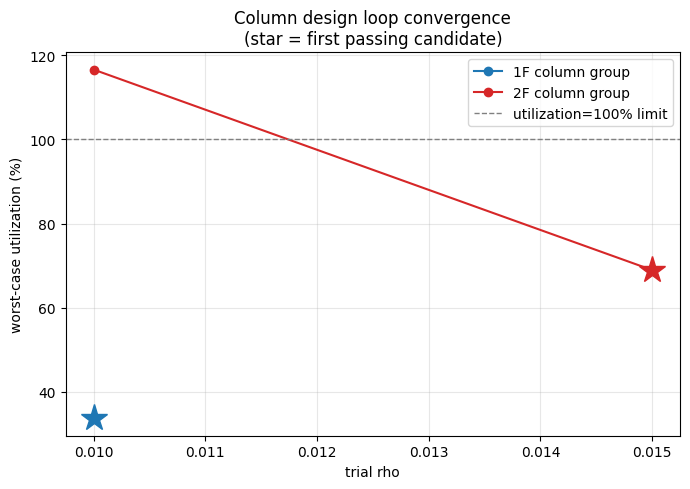

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
for log, label, color in [(log_1F, '1F column group', 'C0'), (log_2F, '2F column group', 'C3')]:
    rhos = [x[0] for x in log]
    utils = [x[1]*100 for x in log]
    oks = [x[2] for x in log]
    ax.plot(rhos, utils, 'o-', color=color, label=label)
    for r, u, ok in zip(rhos, utils, oks):
        if ok:
            ax.plot(r, u, '*', color=color, ms=20, zorder=5)
            break
ax.axhline(100, color='gray', ls='--', lw=1, label='utilization=100% limit')
ax.set_xlabel('trial rho')
ax.set_ylabel('worst-case utilization (%)')
ax.set_title('Column design loop convergence\n(star = first passing candidate)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 梁設計(1F梁 + 屋頂梁)

`design_rebar()` 是直接解出來的,不需要候選清單迴圈。Stage 3 只做過
1F梁,這裡補齊屋頂梁。

In [5]:
b_beam_cm, h_beam_cm = b_beam*100, h_beam*100

def design_beam(member_end, member_mid):
    g = governing(by_member[member_end])
    Mu_neg = abs(g['M_i'][0])
    mid_recs = by_member[member_mid]
    Mu_pos = max(abs(r['M']) for r in mid_recs)
    Vu = abs(g['V_i'][0])
    top = design_rebar(Mu_neg, b_beam_cm, h_beam_cm, fc=280.0, fy=4200.0)
    bot = design_rebar(Mu_pos, b_beam_cm, h_beam_cm, fc=280.0, fy=4200.0)
    shear = design_stirrups(Vu, b_beam_cm, top['d'], fc=280.0, fyv=2800.0)
    return dict(Mu_neg=Mu_neg, Mu_pos=Mu_pos, Vu=Vu, top=top, bot=bot, shear=shear)

d_1F = design_beam('beam1F', 'beam1F_mid')
d_RF = design_beam('beamRF', 'beamRF_mid')

for name, d in [('1F beam', d_1F), ('Roof beam', d_RF)]:
    print(f"=== {name} ===")
    print(f"Mu(-)={d['Mu_neg']:.2f}kN-m Mu(+)={d['Mu_pos']:.2f}kN-m Vu={d['Vu']:.2f}kN")
    print(f"  TOP:    {d['top']['n_bars']}-{d['top']['bar_size']}, "
          f"phiMn={d['top']['phiMn_provided']:.2f}, 利用率={d['Mu_neg']/d['top']['phiMn_provided']:.1%}")
    print(f"  BOTTOM: {d['bot']['n_bars']}-{d['bot']['bar_size']}, "
          f"phiMn={d['bot']['phiMn_provided']:.2f}, 利用率={d['Mu_pos']/d['bot']['phiMn_provided']:.1%}")
    print(f"  STIRRUP: {d['shear']['bar_size']} @ {d['shear']['spacing_cm']}cm")
    print()

=== 1F beam ===
Mu(-)=157.09kN-m Mu(+)=94.32kN-m Vu=167.61kN
  TOP:    4-#6(D19), phiMn=171.75, 利用率=91.5%
  BOTTOM: 2-#7(D22), phiMn=119.17, 利用率=79.2%
  STIRRUP: #4(D13) @ 20cm

=== Roof beam ===
Mu(-)=142.13kN-m Mu(+)=109.28kN-m Vu=167.61kN
  TOP:    5-#5(D16), phiMn=150.48, 利用率=94.5%
  BOTTOM: 2-#7(D22), phiMn=119.17, 利用率=91.7%
  STIRRUP: #4(D13) @ 20cm



## Stage 4 設計結果總表

In [6]:
print(f"{'構件':<12}{'配筋':<28}{'utilization':>12}")
print("-"*54)
print(f"{'1F beam TOP':<12}{d_1F['top']['n_bars']}-{d_1F['top']['bar_size']:<24}"
      f"{d_1F['Mu_neg']/d_1F['top']['phiMn_provided']:>11.1%}")
print(f"{'1F beam BOT':<12}{d_1F['bot']['n_bars']}-{d_1F['bot']['bar_size']:<24}"
      f"{d_1F['Mu_pos']/d_1F['bot']['phiMn_provided']:>11.1%}")
print(f"{'RF beam TOP':<12}{d_RF['top']['n_bars']}-{d_RF['top']['bar_size']:<24}"
      f"{d_RF['Mu_neg']/d_RF['top']['phiMn_provided']:>11.1%}")
print(f"{'RF beam BOT':<12}{d_RF['bot']['n_bars']}-{d_RF['bot']['bar_size']:<24}"
      f"{d_RF['Mu_pos']/d_RF['bot']['phiMn_provided']:>11.1%}")
print(f"{'1F column':<12}{'rho='+str(rho_1F)+' (3+2+3 layout)':<28}{worst_1F[0]:>11.1%}")
print(f"{'2F column':<12}{'rho='+str(rho_2F)+' (3+2+3 layout)':<28}{worst_2F[0]:>11.1%}")

assert worst_1F[0] <= 1.0 and worst_2F[0] <= 1.0
print("\n[PASS] 所有構件在Design Loop收斂的配筋下, 全部6組合的governing demand都在容量內")

構件          配筋                           utilization
------------------------------------------------------
1F beam TOP 4-#6(D19)                       91.5%
1F beam BOT 2-#7(D22)                       79.2%
RF beam TOP 5-#5(D16)                       94.5%
RF beam BOT 2-#7(D22)                       91.7%
1F column   rho=0.01 (3+2+3 layout)           33.7%
2F column   rho=0.015 (3+2+3 layout)          68.9%

[PASS] 所有構件在Design Loop收斂的配筋下, 全部6組合的governing demand都在容量內


## 柱 P-M 圖(收斂後的最終配筋)

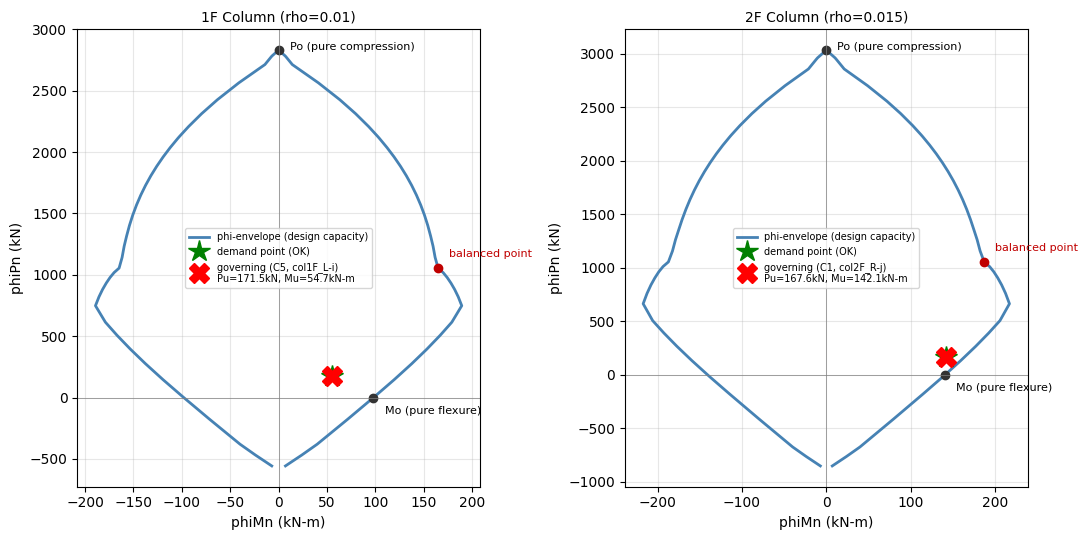

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
from rc_design import draw_PM_interaction

for ax, (name, worst, rho) in zip(axes, [('1F Column', worst_1F, rho_1F), ('2F Column', worst_2F, rho_2F)]):
    util, combo, member, end, Pu, Mu, res = worst
    draw_PM_interaction(res, title=f"{name} (rho={rho})", ax=ax)
    ax.plot(Mu, Pu, 'X', color='red', ms=14,
            label=f'governing ({combo}, {member}-{end})\nPu={Pu:.1f}kN, Mu={Mu:.1f}kN-m')
    ax.legend(fontsize=7, loc='best')
plt.tight_layout()
plt.show()

## Stage 4 小結

- **柱**:用正式 Design Loop(每個候選檢查全部6組合×兩端)收斂,
  2F柱組需要比1F柱組更大的配筋率才能通過(見上面收斂過程圖),
  跟 Stage 3 已發現的「2F柱組較臨界」一致
- **梁**:1F梁+屋頂梁都完成頂部/底部/箍筋設計,`design_rebar()`直接
  解出來不需要迴圈

**明確還沒做的**(留給 Stage 5):
1. 強柱弱梁檢核(ΣMnc ≥ 1.2ΣMnb)完全沒做——這一課的柱配筋只保證
   「扛得住需求」,沒有檢查「柱容量是否確實大於梁容量的1.2倍」
2. 剪力設計還是彈性需求剪力,沒有涵蓋塑鉸機制剪力(capacity design shear)
3. 只做了 Y向1跨2柱這個最簡單複雜度,X向3跨4柱、完整8柱3D模型還沒做
4. 目前的柱配筋是 Design Loop 收斂到的**第一個**通過候選,不是全域
   最經濟解(候選清單本身是離散的,實際可能存在更小但沒被列入候選
   清單的 ρ 也足夠)

**下一步是 Stage 5**:強柱弱梁檢核 + 規範檢核清單。